In [32]:
import duckdb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder 
from sklearn.cluster import KMeans
from scipy import stats
from sklearn.manifold import TSNE
import umap.umap_ as umap

In [33]:
Data=pd.read_csv("term-deposit-marketing-2020.csv")
Data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In [34]:
Data["job"].replace(["unknown"],Data["job"].mode(),inplace = True)
Data["education"].replace(["unknown"],Data["education"].mode(),inplace = True)
Data["contact"].replace(["unknown"],Data["contact"].mode(),inplace = True)

In [35]:
lbe = LabelEncoder()
Data['job'] = lbe.fit_transform(Data['job'])
Data['marital'] = lbe.fit_transform(Data['marital'])
Data['education'] = lbe.fit_transform(Data['education'])
Data['default'] = lbe.fit_transform(Data['default'])
Data['housing'] = lbe.fit_transform(Data['housing'])
Data['contact'] = lbe.fit_transform(Data['contact'])
Data['month'] = lbe.fit_transform(Data['month'])
Data['loan'] = lbe.fit_transform(Data['loan'])
Data['y'] = lbe.fit_transform(Data['y'])
Data.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,4,1,2,0,2143,1,0,0,5,8,261,1,0
1,44,9,2,1,0,29,1,0,0,5,8,151,1,0
2,33,2,1,1,0,2,1,1,0,5,8,76,1,0
3,47,1,1,1,0,1506,1,0,0,5,8,92,1,0
4,33,1,2,1,0,1,0,0,0,5,8,198,1,0


In [36]:
result = duckdb.sql("""
    SELECT 
        *
    FROM 
        Data 
    where 
                    y = '1'
""").df() # Fetch the result as a pandas DataFrame

result.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,59,0,1,1,0,2343,1,0,0,5,8,1042,1,1
1,56,0,1,1,0,45,0,0,0,5,8,1467,1,1
2,41,9,1,1,0,1270,1,0,0,5,8,1389,1,1
3,55,7,1,1,0,2476,1,0,0,5,8,579,1,1
4,54,0,1,2,0,184,0,0,0,5,8,673,2,1


- Here, The dataset shows considerable variation in variable magnitudes. Variables such as Job, Default, and Housing exhibit relatively low values, while Balance and Duration display much higher magnitudes.

- Since K-Means is a distance-based algorithm, this difference in magnitude can create a problem.

In [37]:
result.describe()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
count,2896.000000,2896.000000,2896.000000,2896.000000,2896.000000,2896.000000,2896.000000,2896.000000,2896.000000,2896.000000,2896.000000,2896.000000,2896.000000,2896.0
mean,39.844959,4.410566,1.219613,1.233425,0.016920,1588.495856,0.505525,0.131215,0.057320,15.827003,5.029006,682.958564,2.414365,1.0
std,11.001984,3.242360,0.664502,0.650283,0.128994,2924.894429,0.500056,0.337694,0.232494,8.557604,3.197882,431.287174,2.306015,0.0
min,19.000000,0.000000,0.000000,0.000000,0.000000,-3058.000000,0.000000,0.000000,0.000000,1.000000,0.000000,8.000000,1.000000,1.0
25%,31.000000,1.000000,1.000000,1.000000,0.000000,141.000000,0.000000,0.000000,0.000000,8.000000,1.000000,364.000000,1.000000,1.0
50%,37.000000,4.000000,1.000000,1.000000,0.000000,620.000000,1.000000,0.000000,0.000000,16.000000,6.000000,629.000000,2.000000,1.0
75%,47.000000,7.000000,2.000000,2.000000,0.000000,1820.500000,1.000000,0.000000,0.000000,22.000000,8.000000,913.000000,3.000000,1.0
max,95.000000,10.000000,2.000000,2.000000,1.000000,45248.000000,1.000000,1.000000,1.000000,31.000000,10.000000,3881.000000,32.000000,1.0


In [38]:
# standardizing the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(result)

# statistics of scaled data
pd.DataFrame(data_scaled).describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
count,2.896000e+03,2.896000e+03,2.896000e+03,2.896000e+03,2.896000e+03,2.896000e+03,2896.000000,2.896000e+03,2.896000e+03,2.896000e+03,2.896000e+03,2896.000000,2.896000e+03,2896.0
mean,2.944238e-17,1.177695e-16,-2.944238e-17,1.030483e-16,3.925650e-17,2.208178e-17,0.000000,-7.851301e-17,-7.851301e-17,-1.275836e-16,1.373978e-16,0.000000,3.925650e-17,0.0
std,1.000173e+00,1.000173e+00,1.000173e+00,1.000173e+00,1.000173e+00,1.000173e+00,1.000173,1.000173e+00,1.000173e+00,1.000173e+00,1.000173e+00,1.000173,1.000173e+00,0.0
min,-1.894982e+00,-1.360530e+00,-1.835695e+00,-1.897078e+00,-1.311911e-01,-1.588877e+00,-1.011111,-3.886301e-01,-2.465884e-01,-1.732911e+00,-1.572877e+00,-1.565257,-6.134429e-01,0.0
25%,-8.040810e-01,-1.052059e+00,-3.305499e-01,-3.590215e-01,-1.311911e-01,-4.949737e-01,-1.011111,-3.886301e-01,-2.465884e-01,-9.147835e-01,-1.260116e+00,-0.739678,-6.134429e-01,0.0
50%,-2.586306e-01,-1.266476e-01,-3.305499e-01,-3.590215e-01,-1.311911e-01,-3.311788e-01,0.989011,-3.886301e-01,-2.465884e-01,2.021911e-02,3.036892e-01,-0.125132,-1.797196e-01,0.0
75%,6.504533e-01,7.987642e-01,1.174596e+00,1.179035e+00,-1.311911e-01,7.933422e-02,0.989011,-3.886301e-01,-2.465884e-01,7.214710e-01,9.292112e-01,0.533476,2.540037e-01,0.0
max,5.014056e+00,1.724176e+00,1.174596e+00,1.179035e+00,7.622469e+00,1.492944e+01,0.989011,2.573141e+00,4.055340e+00,1.773349e+00,1.554733e+00,7.416390,1.283198e+01,0.0


In [39]:
data_scaled=pd.DataFrame(data_scaled, columns=result.columns)

In [40]:
# defining the kmeans function with initialization as k-means++
Model_kmeans = KMeans(n_clusters=2, init='k-means++')

# fitting the k means algorithm on scaled data
Model_kmeans.fit(data_scaled.drop('y', axis=1))

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


Text(0, 0.5, 'Inertia')

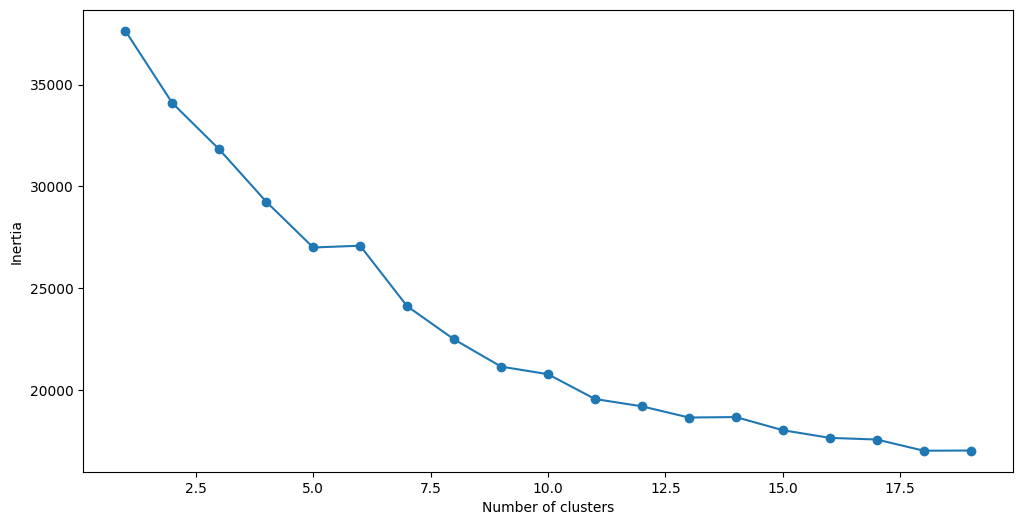

In [41]:
SSE = []
for cluster in range(1,20):
    kmeans = KMeans(n_init=1, n_clusters = cluster, init='k-means++')
    kmeans.fit(data_scaled)
    SSE.append(kmeans.inertia_)

# converting the results into a dataframe and plotting them
frame = pd.DataFrame({'Cluster':range(1,20), 'SSE':SSE})
plt.figure(figsize=(12,6))
plt.plot(frame['Cluster'], frame['SSE'], marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

- Looking at the above elbow curve, we can choose any number of clusters between 7 to 10.

In [42]:
kmeans_8 = KMeans(n_init=1, n_clusters = 8, init='k-means++')
kmeans_8.fit(data_scaled)
pred=kmeans_8.predict(data_scaled)


T-distributed stochastic neighbor embedding (t-SNE)

In [43]:
tsne = TSNE(n_components=2, random_state=4230)
tsne_results = tsne.fit_transform(data_scaled)

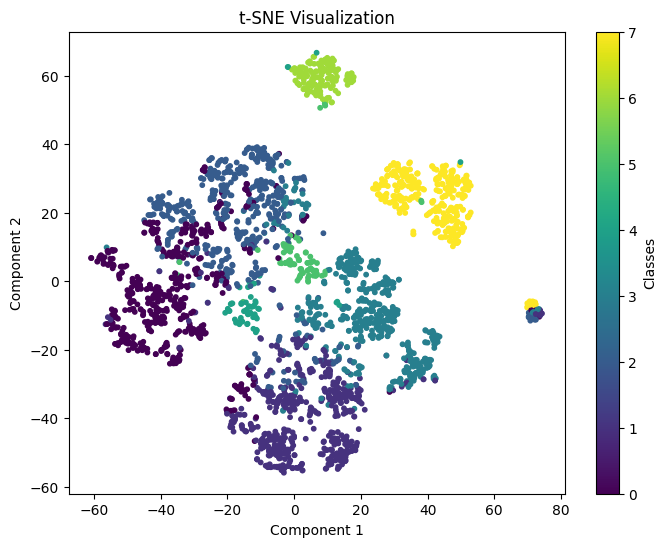

In [44]:

# Plot t-SNE results
labels = pred 
plt.figure(figsize=(8, 6))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap='viridis', s=10)
plt.title("t-SNE Visualization")
plt.ylabel("Component 2")
plt.xlabel("Component 1")
plt.colorbar(label='Classes')
plt.show()

- I created a DataFrame using the default setting of n_components=2, which defines the dimension of the embedded space. This results in two features, component_1 and     component_2, with the t-SNE results as their values

- Add original features from Data_Scaled Dataframe

- Add cluster labels from KMeans

- Mean and mode by cluster and Combine into one table 

In [45]:
# build a dataframe for the 2 TSNE components 
df_tsne = pd.DataFrame(data=tsne_results, columns=['Component 1', 'Component 2'])

df_tsne[tsne.feature_names_in_] = data_scaled[tsne.feature_names_in_]  # add original features for stats


df_tsne['cluster'] = pred  # add cluster labels from KMeans
# Mean per cluster
cluster_means = df_tsne.groupby('cluster').mean()

# Mode per cluster (apply mode to each column in the group)
cluster_modes = df_tsne.groupby('cluster').agg(lambda x: stats.mode(x, keepdims=True).mode[0])

# Combine into one table and keep the same variable name used later
cluster_stats = pd.concat([cluster_means, cluster_modes], keys=['Mean', 'Mode']).swaplevel(0,1).sort_index()

print(cluster_stats)


              Component 1  Component 2       age       job   marital  \
cluster                                                                
0       Mean   -35.834026    -3.314056 -0.647213  0.297169  0.691813   
        Mode   -60.908791   -46.718750 -0.622264 -0.126648  1.174596   
1       Mean     3.344338   -37.402771 -0.376505  0.688635  0.292361   
        Mode   -56.567249   -55.955952 -0.713173  1.415705  1.174596   
2       Mean   -14.482550    15.677503  1.064970  0.090546 -0.792021   
        Mode   -44.969543   -31.281334  1.195904 -0.126648 -0.330550   
3       Mean    21.963688    -9.104836 -0.149169 -0.986817 -0.146246   
        Mode   -56.252609   -37.889641 -0.440447 -1.052059 -0.330550   
4       Mean   -11.101870    -3.969087 -0.095304  0.187051  0.358245   
        Mode   -20.688307   -14.944275 -0.713173 -0.126648  1.174596   
5       Mean     1.693760     8.100883  0.065878 -0.138362 -0.140025   
        Mode   -34.891651    -6.034009 -0.894989 -0.126648 -0.33

In [46]:
df_tsne.shape

(2896, 17)

In [47]:
# Reset index to flatten the table
cluster_stats_reset = cluster_stats.reset_index()

# Rename columns for clarity
cluster_stats_reset.rename(columns={'level_0':'Cluster','level_1':'Statistic'}, inplace=True)

# Display nicely in Jupyter
cluster_stats_reset



,cluster,Statistic,Component 1,Component 2,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,0,Mean,-35.834026,-3.314056,-0.647213,0.297169,0.691813,0.580169,-0.091292,-0.093498,-0.884174,-0.388630,-0.246588,0.225102,-0.644250,-0.416822,-0.123923,0.0
1,0,Mode,-60.908791,-46.718750,-0.622264,-0.126648,1.174596,1.179035,-0.131191,-0.543189,-1.011111,-0.388630,-0.246588,1.656474,-1.572877,-1.057387,-0.613443,0.0
2,1,Mean,3.344338,-37.402771,-0.376505,0.688635,0.292361,0.370394,0.006529,-0.097640,0.925064,-0.388630,-0.246588,-0.121983,0.409239,0.210470,-0.128104,0.0
3,1,Mode,-56.567249,-55.955952,-0.713173,1.415705,1.174596,1.179035,-0.131191,-0.543189,0.989011,-0.388630,-0.246588,0.253970,0.929211,-0.340803,-0.613443,0.0
4,2,Mean,-14.482550,15.677503,1.064970,0.090546,-0.792021,-0.095825,0.034663,0.002122,-0.793629,-0.388630,-0.246588,-0.169365,-0.347478,-0.204637,-0.132559,0.0
5,2,Mode,-44.969543,-31.281334,1.195904,-0.126648,-0.330550,-0.359021,-0.131191,-0.543189,-1.011111,-0.388630,-0.246588,-1.265409,-1.260116,-1.268419,-0.613443,0.0
6,3,Mean,21.963688,-9.104836,-0.149169,-0.986817,-0.146246,-0.807027,-0.001724,-0.162058,0.829446,-0.388630,-0.246588,-0.035942,0.433668,0.321591,-0.191790,0.0
7,3,Mode,-56.252609,-37.889641,-0.440447,-1.052059,-0.330550,-0.359021,-0.131191,-0.543189,0.989011,-0.388630,-0.246588,0.253970,0.929211,-1.235953,-0.613443,0.0
8,4,Mean,-11.101870,-3.969087,-0.095304,0.187051,0.358245,0.527316,-0.131191,4.821553,-0.299204,-0.288231,0.045068,0.045971,0.112852,-0.219505,0.077574,0.0
9,4,Mode,-20.688307,-14.944275,-0.713173,-0.126648,1.174596,1.179035,-0.131191,3.853284,-1.011111,-0.388630,-0.246588,0.253970,0.929211,-1.217401,-0.613443,0.0


- Uniform Manifold Approximation and Projection (UMAP)

c:\Users\Dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


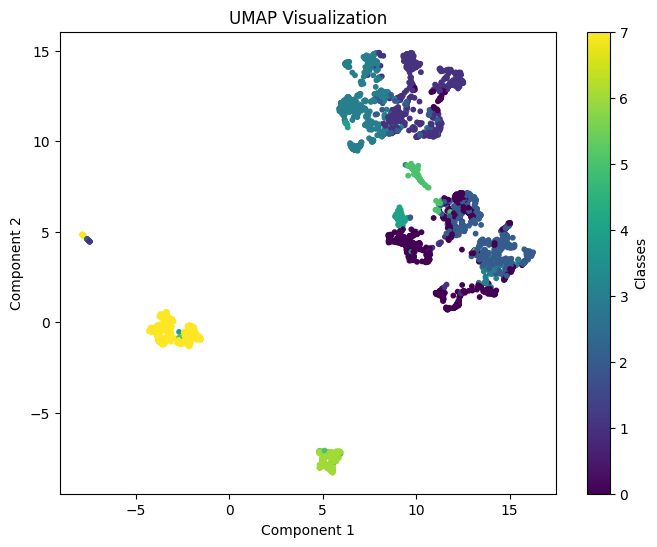

In [48]:
# Apply UMAP
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=4230)
umap_results = umap_model.fit_transform(data_scaled) 

# Plot UMAP results
plt.figure(figsize=(8, 6))
plt.scatter(umap_results[:, 0], umap_results[:, 1], c=labels, cmap='viridis', s=10)
plt.title("UMAP Visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label='Classes')
plt.show()

In [49]:
labels.shape

(2896,)

In [50]:
# build a dataframe for the 2 TSNE components (avoid using an existing 'df' variable)
df_umap = pd.DataFrame(data=umap_results, columns=['Component 1', 'Component 2'])

df_umap[tsne.feature_names_in_] = data_scaled[tsne.feature_names_in_].values  # add original features for stats
df_umap['Cluster'] = pred  # add cluster labels from KMeans
# Mean per clustera
cluster_umap_means = df_umap.groupby('Cluster').mean()

# Mode per cluster (apply mode to each column in the group)
cluster_umap_modes = df_umap.groupby('Cluster').agg(lambda x: stats.mode(x, keepdims=True).mode[0])

# Combine into one table and keep the same variable name used later
cluster_umap_stats = pd.concat([cluster_umap_means, cluster_umap_modes], keys=['Mean', 'Mode']).swaplevel(0,1).sort_index()

print(cluster_umap_stats)

              Component 1  Component 2       age       job   marital  \
Cluster                                                                
0       Mean    11.397017     4.379018 -0.647213  0.297169  0.691813   
        Mode    -7.532933     0.707007 -0.622264 -0.126648  1.174596   
1       Mean    10.029831    12.006240 -0.376505  0.688635  0.292361   
        Mode    -7.538542     1.609313 -0.713173  1.415705  1.174596   
2       Mean    12.928909     5.254025  1.064970  0.090546 -0.792021   
        Mode    -7.614975     2.141295  1.195904 -0.126648 -0.330550   
3       Mean     7.480102    11.160459 -0.149169 -0.986817 -0.146246   
        Mode    -7.522095     1.943541 -0.440447 -1.052059 -0.330550   
4       Mean     8.755073     5.436792 -0.095304  0.187051  0.358245   
        Mode    -2.684203    -7.754908 -0.713173 -0.126648  1.174596   
5       Mean     9.735972     6.676491  0.065878 -0.138362 -0.140025   
        Mode    -2.685473    -7.147725 -0.894989 -0.126648 -0.33

In [51]:
# Reset index to flatten the table
cluster_stats_reset_umap = cluster_umap_stats.reset_index()

# Rename columns for clarity
cluster_stats_reset_umap.rename(columns={'level_0':'Cluster','level_1':'Statistic'}, inplace=True)

# Display nicely in Jupyter
cluster_stats_reset_umap


,Cluster,Statistic,Component 1,Component 2,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,0,Mean,11.397017,4.379018,-0.647213,0.297169,0.691813,0.580169,-0.091292,-0.093498,-0.884174,-0.388630,-0.246588,0.225102,-0.644250,-0.416822,-0.123923,0.0
1,0,Mode,-7.532933,0.707007,-0.622264,-0.126648,1.174596,1.179035,-0.131191,-0.543189,-1.011111,-0.388630,-0.246588,1.656474,-1.572877,-1.057387,-0.613443,0.0
2,1,Mean,10.029831,12.006240,-0.376505,0.688635,0.292361,0.370394,0.006529,-0.097640,0.925064,-0.388630,-0.246588,-0.121983,0.409239,0.210470,-0.128104,0.0
3,1,Mode,-7.538542,1.609313,-0.713173,1.415705,1.174596,1.179035,-0.131191,-0.543189,0.989011,-0.388630,-0.246588,0.253970,0.929211,-0.340803,-0.613443,0.0
4,2,Mean,12.928909,5.254025,1.064970,0.090546,-0.792021,-0.095825,0.034663,0.002122,-0.793629,-0.388630,-0.246588,-0.169365,-0.347478,-0.204637,-0.132559,0.0
5,2,Mode,-7.614975,2.141295,1.195904,-0.126648,-0.330550,-0.359021,-0.131191,-0.543189,-1.011111,-0.388630,-0.246588,-1.265409,-1.260116,-1.268419,-0.613443,0.0
6,3,Mean,7.480102,11.160459,-0.149169,-0.986817,-0.146246,-0.807027,-0.001724,-0.162058,0.829446,-0.388630,-0.246588,-0.035942,0.433668,0.321591,-0.191790,0.0
7,3,Mode,-7.522095,1.943541,-0.440447,-1.052059,-0.330550,-0.359021,-0.131191,-0.543189,0.989011,-0.388630,-0.246588,0.253970,0.929211,-1.235953,-0.613443,0.0
8,4,Mean,8.755073,5.436792,-0.095304,0.187051,0.358245,0.527316,-0.131191,4.821553,-0.299204,-0.288231,0.045068,0.045971,0.112852,-0.219505,0.077574,0.0
9,4,Mode,-2.684203,-7.754908,-0.713173,-0.126648,1.174596,1.179035,-0.131191,3.853284,-1.011111,-0.388630,-0.246588,0.253970,0.929211,-1.217401,-0.613443,0.0
